# fashion_minst分类实战

In [17]:
import torch
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),#将PIL.Image变换成torch.Tensor，并且将像素值归一化到[0,1]
])

# 下载并加载训练数据集
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=False, transform=transform)

# 从训练集中分出5000样本作为验证集
train_size = len(full_train_dataset) - 5000
val_size = 5000
#random_split打乱样本
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size],generator=generator)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # batch_size是一个批次样本的数量
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# 下载并加载测试数据集
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

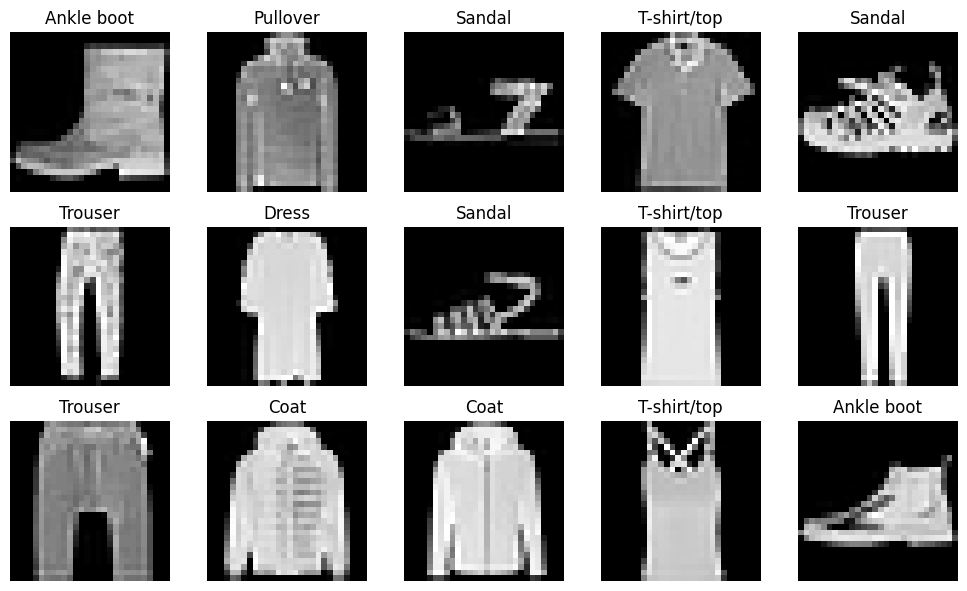

In [18]:
import matplotlib.pyplot as plt

# FashionMNIST类别名称
class_names = full_train_dataset.classes

# 可视化train_dataset前15个样本，并显示类别名称
fig, axs = plt.subplots(3, 5, figsize=(10, 6))
axs = axs.flatten()

for i in range(15):
    # 这里train_dataset[i]会返回(img, label)两个值，
    # img是第i个样本的图像（已做Tensor变换），label是对应的类别标签。
    # 因为train_dataset由torch.utils.data.random_split分割自原始的Dataset，继承了其__getitem__方法，原始FashionMNIST的__getitem__返回图像和标签两个值。
    img, label = train_dataset[i]
    img = img.squeeze().numpy()  # 变成2D numpy数组  将(1,28,28)压缩成(28,28)
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(class_names[label])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
import torch.nn as nn

class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()
        # 第一组卷积层：Conv1+Conv2+池化
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        # 第二组卷积层：Conv3+Conv4+池化
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        # 第三组卷积层：Conv5+Conv6+池化
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu5 = nn.ReLU()
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.relu6 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        # 经过3次池化，每次尺寸减半：28->14->7->3(向下取整)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.relu_fc1 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.relu1(self.conv1(x))
        x = self.relu2(self.conv2(x))
        x = self.pool1(x)

        x = self.relu3(self.conv3(x))
        x = self.relu4(self.conv4(x))
        x = self.pool2(x)

        x = self.relu5(self.conv5(x))
        x = self.relu6(self.conv6(x))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)
        x = self.relu_fc1(self.fc1(x))
        x = self.fc2(x)
        return x

In [20]:
model = ConvNet()
# 随机生成一个输入数据，进行向前传播
import torch

# 假设输入为单张28x28的灰度图片，模拟batch size为1
dummy_input = torch.randn(4, 1, 28, 28)
# 将输入放到相应设备
dummy_input = dummy_input.to(next(model.parameters()).device)
# 向前传播
with torch.no_grad():
    output = model(dummy_input)
print("Output logits:", output.size())

Output logits: torch.Size([4, 10])


In [21]:
def count_parameters(model):
    """
    输出模型每层的参数量及总参数量
    """
    total_params = 0
    print("{:<30} {:<20}".format("Layer Name", "Num Params"))
    print("-" * 50)
    for name, param in model.named_parameters():
        if param.requires_grad:
            param_count = param.numel()
            print("{:<30} {:<20}".format(name, param_count))
            total_params += param_count
    print("-" * 50)
    print("Total parameters: {}".format(total_params))

# 计数、展示 ConvNet 各层参数量
count_parameters(model)

Layer Name                     Num Params          
--------------------------------------------------
conv1.weight                   288                 
conv1.bias                     32                  
conv2.weight                   9216                
conv2.bias                     32                  
conv3.weight                   18432               
conv3.bias                     64                  
conv4.weight                   36864               
conv4.bias                     64                  
conv5.weight                   73728               
conv5.bias                     128                 
conv6.weight                   147456              
conv6.bias                     128                 
fc1.weight                     147456              
fc1.bias                       128                 
fc2.weight                     1280                
fc2.bias                       10                  
--------------------------------------------------
Total paramete

In [22]:
import torch
import torch.optim as optim

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 设置交叉熵损失函数和SGD优化器
criterion = nn.CrossEntropyLoss()  # 默认求的是样本的平均损失
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
   

Epoch [1/20], Step [100/860], Loss: 2.3045
Epoch [1/20], Step [200/860], Loss: 2.2923
Epoch [1/20], Step [300/860], Loss: 1.2018
Epoch [1/20], Step [400/860], Loss: 0.8948
Epoch [1/20], Step [500/860], Loss: 0.7081
Epoch [1/20], Step [600/860], Loss: 0.5629
Epoch [1/20], Step [700/860], Loss: 0.7512
Epoch [1/20], Step [800/860], Loss: 0.5369
Epoch [1/20], Train Loss: 1.1782, Train Acc: 81.53%, Val Loss: 0.5309, Val Acc: 80.84%
Best model saved at epoch 1.
Epoch [2/20], Step [100/860], Loss: 0.4132
Epoch [2/20], Step [200/860], Loss: 0.5269
Epoch [2/20], Step [300/860], Loss: 0.5587
Epoch [2/20], Step [400/860], Loss: 0.5778
Epoch [2/20], Step [500/860], Loss: 0.3872
Epoch [2/20], Step [600/860], Loss: 0.2921
Epoch [2/20], Step [700/860], Loss: 0.4986
Epoch [2/20], Step [800/860], Loss: 0.2361
Epoch [2/20], Train Loss: 0.4075, Train Acc: 87.14%, Val Loss: 0.3795, Val Acc: 85.64%
Best model saved at epoch 2.
Epoch [3/20], Step [100/860], Loss: 0.4179
Epoch [3/20], Step [200/860], Loss: 0

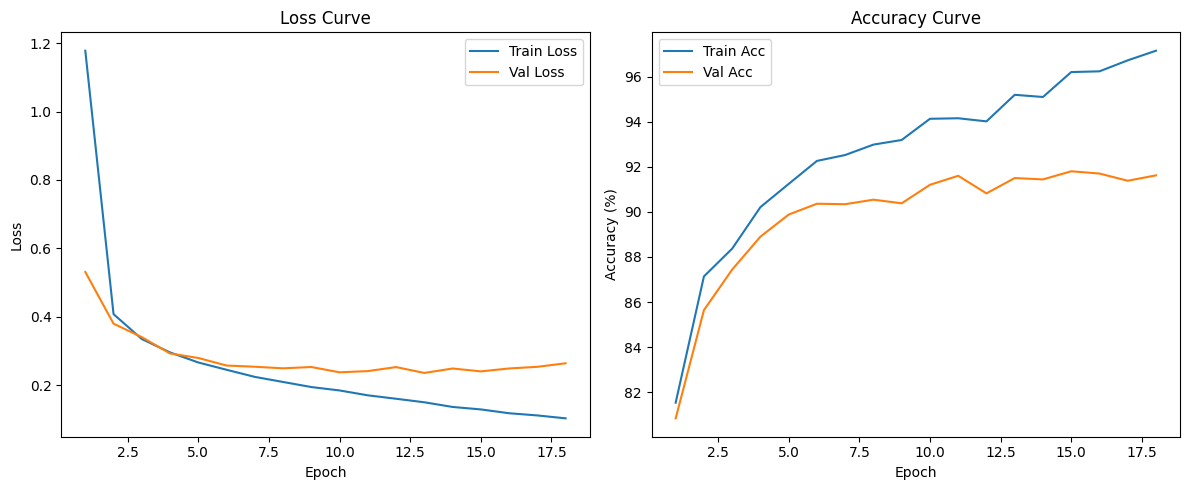

In [23]:
from model_train import Trainer
import torch.optim as optim

# 将模型移至设备
model.to(device)

# 增加优化器
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# 也可以换成其他优化器，比如 Adam，如果需要可以如下替换：
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# 初始化Trainer，启用早停，并保存最佳模型
trainer = Trainer(
    model, 
    train_loader, 
    val_loader, 
    optimizer,     # 增加 optimizer 参数
    lr=0.01, 
    momentum=0.9, 
    device=device, 
    early_stop=True,              # 启用早停
    early_stop_mode='val_loss',   # 可选择 'val_loss' 或 'val_acc'
    patience=5,                   # 早停容忍轮数
    save_path='best_cnn_model.pth' # 保存模型的路径
)
trainer.train(epochs=20)

# 画出损失与准确率曲线
trainer.plot_metrics()


In [24]:
# 在测试集进行评估
# 确保导入 trainer 有 test/evaluate 方法，或直接用 model 预测
# 先将模型设置为评估模式
model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for data, targets in test_loader:
        data, targets = data.to(device), targets.to(device)
        outputs = model(data)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * data.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

test_loss = test_loss / total
accuracy = 100 * correct / total

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {accuracy:.2f}%")

Test Loss: 0.253
Test Accuracy: 91.22%
